# Machine Learning - Day 2

## Unsupervised Learning

### Topics Covered

- K-Means Clustering
- Hierarchical Clustering
- Principal Component Analysis (PCA)
- Bias-Variance Tradeoff
- Cross Validation
- Overfitting & Underfitting

**Goal:** Learn how machines discover hidden patterns in data without using labeled examples, understand model evaluation techniques, and apply these concepts to real-world clustering problems.

# 1. K-Means Clustering

## Description

K-Means Clustering is an unsupervised machine learning algorithm used to group similar data points into a predefined number of clusters (K). The algorithm works by assigning each data point to the nearest cluster centroid and repeatedly updating the centroids until the clusters become stable.

### Applications

- Customer Segmentation
- Image Compression
- Market Basket Analysis
- Document Clustering
- Recommendation Systems

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

np.random.seed(42)

## Genearte Dataset

In [2]:
# Generate synthetic dataset

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

print(X.shape)

(300, 2)


## Visualize the Dataset

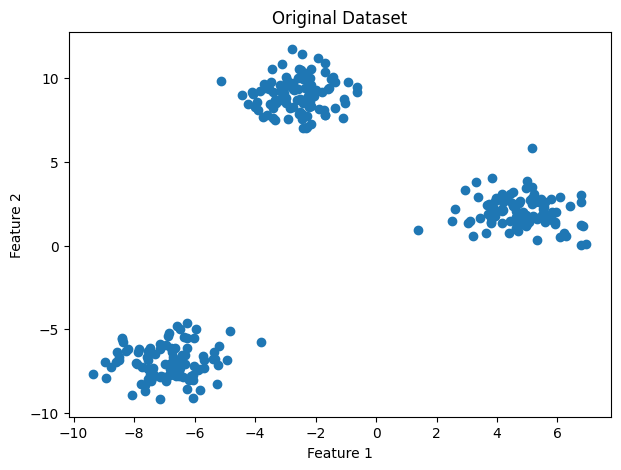

In [3]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1])

plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Train K-Means Model

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

## Predict Clusters

In [5]:
clusters = kmeans.predict(X)

print(clusters[:10])

[1 1 0 2 1 2 0 2 0 0]


## Vizualize Clusters

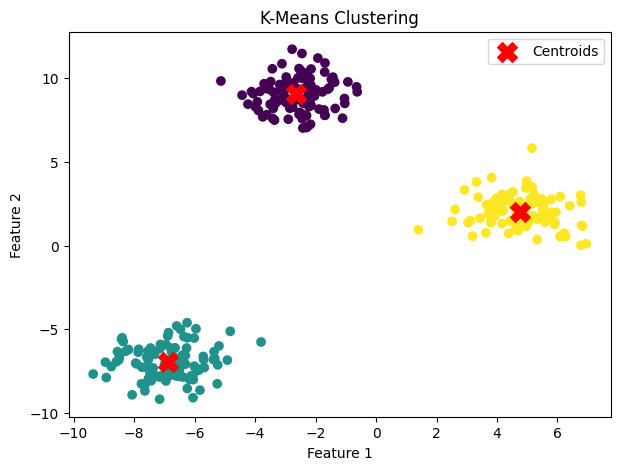

In [6]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap="viridis"
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color="red",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

## Conclusion

- K-Means groups similar data points into clusters.
- The algorithm repeatedly updates cluster centers until convergence.
- The number of clusters (K) must be specified before training.
- K-Means is widely used for customer segmentation and pattern discovery.

# 2. Hierarchical Clustering

## Description

Hierarchical Clustering is an unsupervised machine learning algorithm that groups similar data points into a hierarchy of clusters. Unlike K-Means, it does not require specifying the number of clusters in advance. The result is represented as a tree-like structure called a dendrogram.

### Applications

- Customer Segmentation
- Gene Expression Analysis
- Document Clustering
- Social Network Analysis
- Image Segmentation

## Import Libraries

In [7]:
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

## Generate Dataset

In [8]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

## Plot the Original Data

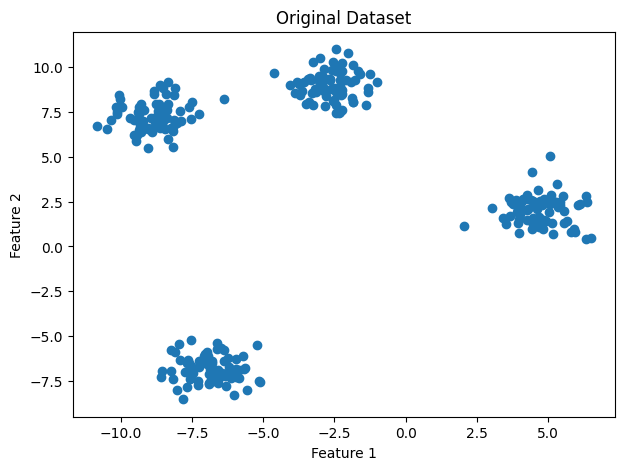

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(X[:,0], X[:,1])

plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Create Dendogram 

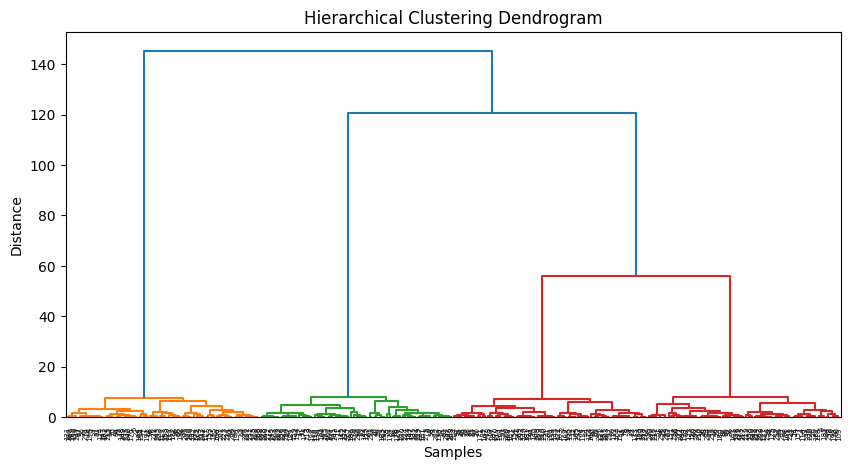

In [10]:
linked = linkage(X, method="ward")

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")

plt.show()

## Train the model

In [11]:
model = AgglomerativeClustering(n_clusters=4)

clusters = model.fit_predict(X)

## Visualize Clusters

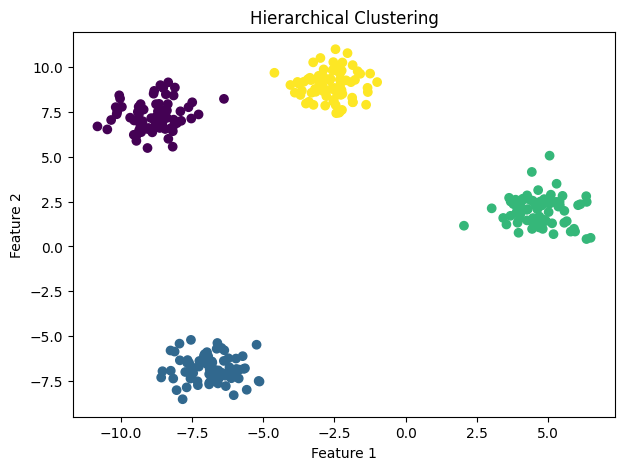

In [12]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("Hierarchical Clustering")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Conclusion

- Hierarchical Clustering builds a hierarchy of clusters.
- It produces a dendrogram to visualize how clusters are formed.
- Unlike K-Means, it does not require choosing K before building the hierarchy.
- It is useful when the natural grouping of the data is unknown.

# 3. Principal Component Analysis (PCA)

## Description

Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset with many features into a smaller set of new features called principal components while preserving as much information (variance) as possible.

### Applications

- Data Visualization
- Noise Reduction
- Image Compression
- Feature Extraction
- Speeding Up Machine Learning Models

## Import Libraries

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

## Load Dataset

In [14]:
iris = load_iris()

X = iris.data
y = iris.target

print("Original Shape:", X.shape)

Original Shape: (150, 4)


## Apply PCA

In [15]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("Reduced Shape:", X_pca.shape)

Reduced Shape: (150, 2)


## Visualize PCA

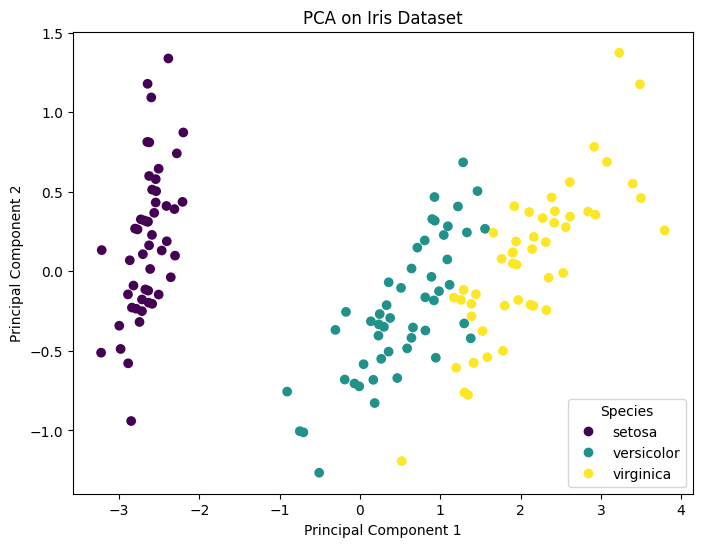

In [17]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")

# Create legend
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Species")

plt.show()

## Explained Varience

In [18]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.92461872 0.05306648]


## Conclusion

- PCA reduces the number of features while preserving most of the important information.
- It helps simplify datasets and improve computational efficiency.
- PCA is widely used before training machine learning models and for visualizing high-dimensional data.

# 4. Bias-Variance Tradeoff

## Description

The Bias-Variance Tradeoff is a fundamental concept in machine learning that explains the balance between underfitting and overfitting. A good model should have low bias and low variance to achieve the best performance on unseen data.

### Key Concepts

- High Bias → Underfitting
- High Variance → Overfitting
- Good Balance → Generalization

## Import Libraries

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

## Generate Dataset

In [20]:
np.random.seed(42)

X = np.linspace(0, 10, 100).reshape(-1, 1)

y = np.sin(X).ravel() + np.random.normal(0, 0.2, 100)

## Create Models

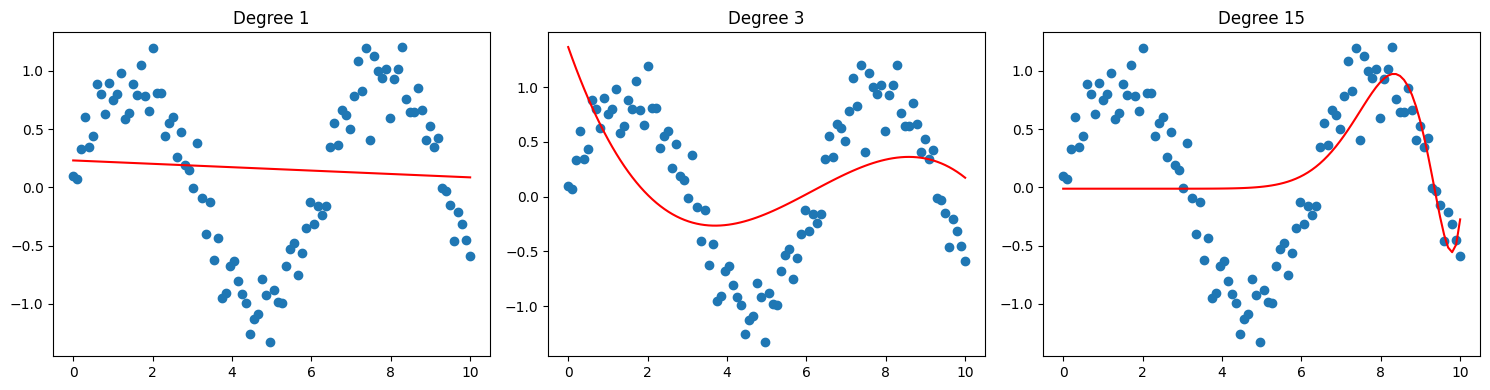

In [21]:
degrees = [1, 3, 15]

plt.figure(figsize=(15, 4))

for i, degree in enumerate(degrees):

    poly = PolynomialFeatures(degree)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    plt.subplot(1, 3, i + 1)

    plt.scatter(X, y)

    plt.plot(X, y_pred, color="red")

    plt.title(f"Degree {degree}")

plt.tight_layout()

plt.show()

## Conclusion

- Degree 1 → High Bias (Underfitting)
- Degree 3 → Good Balance
- Degree 15 → High Variance (Overfitting)

The goal of machine learning is to find the model that generalizes well to new data.

# 5. Cross Validation and Overfitting

## Description

Cross Validation is a model evaluation technique that estimates how well a machine learning model performs on unseen data by splitting the dataset into multiple folds.

Overfitting occurs when a model learns the training data too well, including its noise and outliers, causing poor performance on new data. Underfitting occurs when a model is too simple to capture the underlying patterns in the data.

Cross Validation helps identify whether a model is generalizing well or suffering from overfitting.

### Applications

- Model Evaluation
- Model Selection
- Hyperparameter Tuning
- Detecting Overfitting
- Improving Generalization

## Import Libraries

In [22]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

## Load Dataset

In [23]:
iris = load_iris()

X = iris.data
y = iris.target

## Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train an Overfitting Model

In [25]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 1.0
Testing Accuracy  : 1.0


## Apply Cross Validation

In [26]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.96666667 0.96666667 0.9        0.93333333 1.        ]

Average Accuracy:
0.9533333333333334


## Conclusion

- Cross Validation evaluates a model using multiple train-test splits, giving a more reliable estimate of performance.
- Overfitting occurs when a model performs extremely well on training data but poorly on unseen data.
- Underfitting occurs when a model is too simple and performs poorly on both training and testing data.
- Cross Validation helps detect overfitting and improves confidence that a model will generalize well.